<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/Copy_of_DatasetComparisonToBergik2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ploy(A) tail length comparison across Nano3p-seq datasets

## Mount and load

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/your/path/'  #change dir to your project folder

Mounted at /content/drive/


In [ ]:
!pip install statsmodels

In [ ]:
pip install adjustText

In [ ]:

import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from glob import glob
import adjustText
from scipy.stats import pearsonr


## Nano tail length comparisons

Obtained from Begik 2022  (https://www.nature.com/articles/s41592-022-01714-w#Sec35)


Figure 3G source data

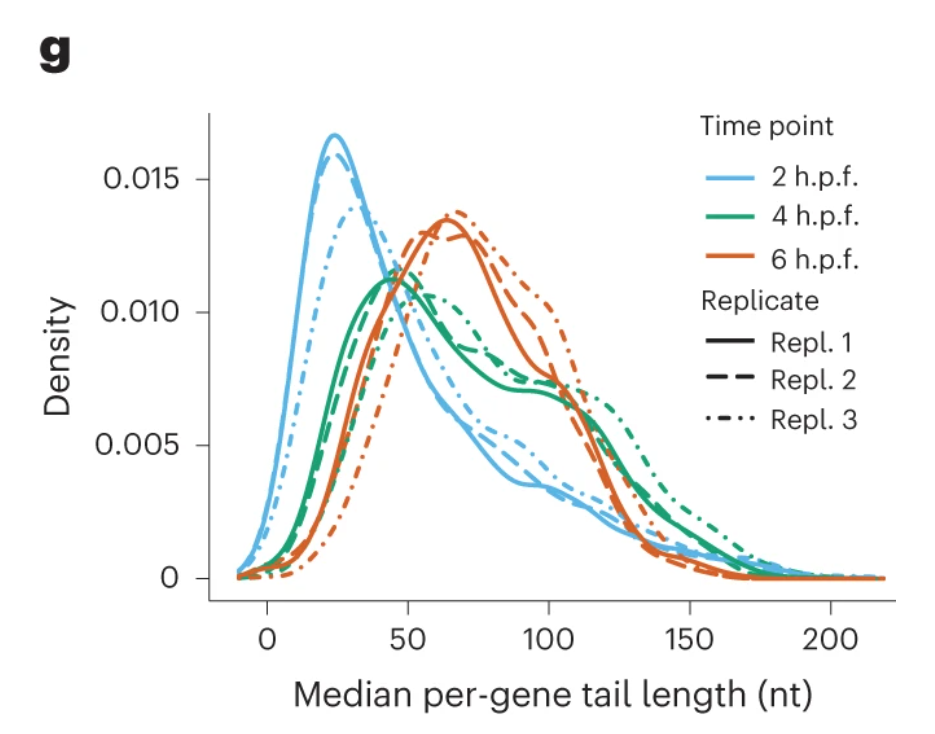

In [ ]:
begik = pd.read_csv('/your/path/Bergik_NatMethods_2022_Fig3G.csv')
begik

,Read_ID,Gene_Name,Biotype,Symbol,Rep,Timepoint,tail_length
0,0001402f-4e46-4b41-80e0-c37694088b44,ENSDARG00000074760,protein_coding,ttc7a,Rep1,2hpf,64.10
1,00019004-1ab2-4fed-91bf-ddd628bf34c8,ENSDARG00000034989,protein_coding,retsatl,Rep1,2hpf,30.34
2,00022f70-0a79-46c0-a10e-035c57a992fa,ENSDARG00000000760,protein_coding,znf511,Rep1,2hpf,5.46
3,0004aed9-e802-4331-bbdb-1041c1c0b48c,ENSDARG00000044540,protein_coding,fkbp2,Rep1,2hpf,23.37
4,0005d2af-a672-4cf6-b9eb-9eff716de3ff,ENSDARG00000036868,protein_coding,tbpl1,Rep1,2hpf,5.83
...,...,...,...,...,...,...,...
530476,fff4ac2b-1533-41fa-b9ae-46834238679a,ENSDARG00000099453,protein_coding,elof1,Rep3,6hpf,172.28
530477,fff5bad7-2c0b-451b-b9d0-d33f1a168b23,ENSDARG00000092807,protein_coding,ENSDARG00000092807,Rep3,6hpf,56.49
530478,fffc0545-883b-4d22-ad74-26a440bbb99e,ENSDARG00000029722,protein_coding,hmgb2a,Rep3,6hpf,89.07
530479,fffcd60d-c5c8-413c-a953-bd456b179e3b,ENSDARG00000053569,protein_coding,sox3,Rep3,6hpf,194.09


In [ ]:
df = pd.read_csv('/your/path/CombinedR1R2_table_annotated.csv', sep = '\t')
df

/tmp/ipython-input-891892265.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Chris/Nano3pSeq/PostPolyTailor/CombinedR1R2_table_annotated.csv', sep = '\t')


,read_id,barcode,mapq,filter,pt_length,per_base,primer_end,pt_start,before_pt,pt_seq,...,exons,additional,comment,Gene,Group,Genotype,Method,Condition,Batch,Adjusted_pt_length
0,b08e7e33-7610-48f3-8ed9-f1a1293ed16f,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,39132-39280,gene_assignment=unique; PolyA=False; Classific...,NaN,XLOC_043623,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
1,1b514c91-eccd-4fe6-b857-1093e4061fcd,SQK-NBD114-24_barcode11,60,not_continuous,-0.2,3.9,100,101,GAGGCAGAGG,TTTTT,...,2235-3171,Classification=intergenic;,NaN,NaN,Hyp_rRNA_T42_2a,Tent5ba42,Hypoxia18,Hypoxia18,Batch1,1.750
2,8ab9bff2-43b2-4696-a238-b6c72f444674,SQK-NBD114-24_barcode07,18,no_primer,0.0,0.0,0,0,NaN,NaN,...,2866-3405,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
3,7f1adb2e-6d1c-483d-8bfc-037643264136,SQK-NBD114-24_barcode08,49,not_continuous,-0.2,2.6,144,149,CAGAGTCTGA,TTTT,...,2877-3141,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_2a,Wildtype,Hypoxia18,Hypoxia18,Batch1,1.750
4,4dd554ec-22ab-4fc3-84d9-0ed13e4c9fa3,SQK-NBD114-24_barcode07,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,3095-3559,Classification=intergenic;,NaN,NaN,Hyp_rRNA_WT_1a,Wildtype,Hypoxia18,Hypoxia18,Batch1,2.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27307111,eddc7366-6312-47a7-b918-5beedcc5abe7,SQK-NBD114-24_barcode13,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16399-16596,gene_assignment=inconsistent_non_intronic; Pol...,NaN,NaN,Hyp_rRNA_WT_1,Wildtype,Hypoxia18,Hypoxia18,Batch2,2.000
27307112,cdbb438e-243c-4122-a166-959b0145e540,SQK-NBD114-24_barcode05,60,OK,10.8,3.5,104,104,CAGAGCAGAG,TTTTTTTTTTTTTTTTTATT,...,16400-16515,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_2,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,15.500
27307113,a25e139b-ff92-4766-8e3b-86a37959dea8,SQK-NBD114-24_barcode16,60,no_primer,0.0,0.0,0,0,NaN,NaN,...,16402-16560,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Hyp_rRNA_T42_1,Tent5ba42,Hypoxia18,Hypoxia18,Batch2,2.000
27307114,4d397346-f635-44df-b346-b6588a666674,SQK-NBD114-24_barcode04,60,OK,12.9,2.9,103,103,CAGAGCAGAG,TTATTTTTTTTTTTTTT,...,16403-16522,gene_assignment=unique_minor_difference; PolyA...,NaN,NaN,Norm_rRNA_T42_1,Tent5ba42,Normoxia6hpf,Normoxia6hpf,Batch2,18.125


In [ ]:
# filter

df = df[df["filter"] == 'OK']

df = df[df["Gene"].notna()]

df = df.loc[df['Group'].isin((
    "Norm_rRNA_WT_1", "Norm_rRNA_WT_2", "Norm_rRNA_WT_3"
))]


In [ ]:
# Get average and median for each gene
result = df.groupby('Gene')['Adjusted_pt_length'].agg(['mean', 'median'])

# If you want to rename the columns
result = result.rename(columns={'mean': 'average', 'median': 'median'})

print(result)

                     average    median
Gene                                  
ABCD2_1_of_many    97.875000   97.8750
ACOT12             80.000000   77.2500
ACSF3              16.250000   16.2500
ADAM12_1_of_many   16.125000   16.1250
ADAMTS7           126.500000  126.5000
...                      ...       ...
zwilch             52.642442   35.3750
zyg11              46.968750   24.1250
zyx                87.324468   70.0000
zzef1             100.268750   81.3125
zzz3               87.593137   75.0000

[18549 rows x 2 columns]


### Median polyA length comparison


Number of genes with >20 reads in both datasets: 1528
Pearson correlation coefficient: 0.7275
R-squared: 0.5293
P-value: 5.4630e-252


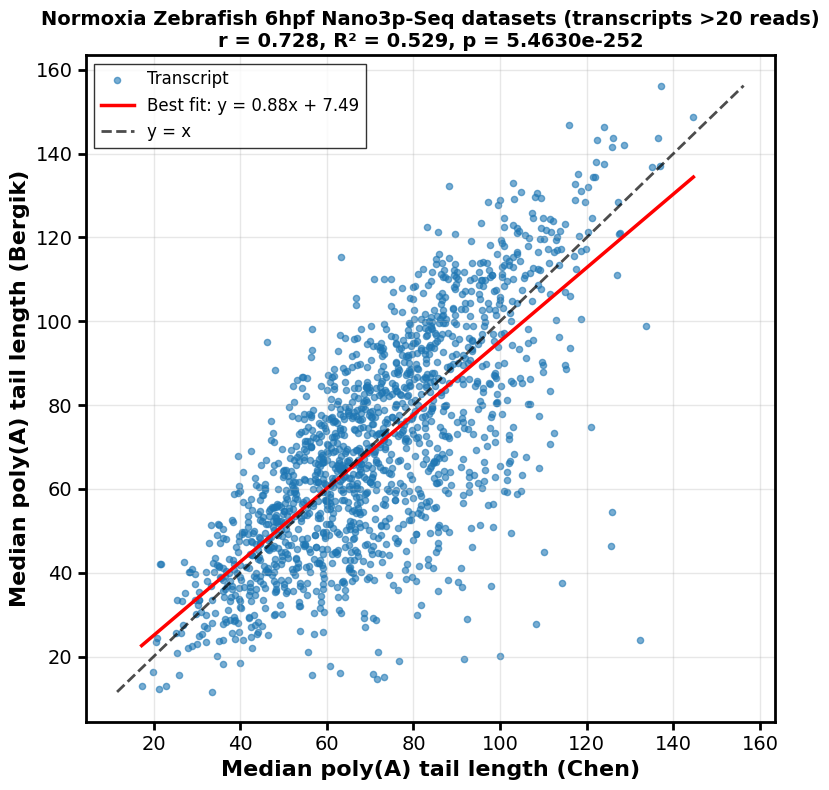

In [ ]:
### Median polyA length comparison

# Filter bergik for 6hpf timepoint only
bergik_6hpf = bergik[bergik['Timepoint'] == '6hpf']

# Count reads per gene and filter for genes with >20 reads
bergik_counts = bergik_6hpf.groupby('Symbol').size()
bergik_genes_over_20 = bergik_counts[bergik_counts > 20].index

# Get median tail_length for genes with >20 reads at 6hpf
tail_medians = bergik_6hpf[bergik_6hpf['Symbol'].isin(bergik_genes_over_20)].groupby('Symbol')['tail_length'].median().reset_index()
tail_medians.columns = ['Symbol', 'median_tail_length']

# Count reads per gene in df and filter for genes with >20 reads
df_counts = df.groupby('Gene').size()
df_genes_over_20 = df_counts[df_counts > 20].index

# Get median adjusted_pt_length for genes with >20 reads
pt_medians = df[df['Gene'].isin(df_genes_over_20)].groupby('Gene')['Adjusted_pt_length'].median().reset_index()
pt_medians.columns = ['Gene', 'median_adjusted_pt']

# Merge the two dataframes on gene name
merged = tail_medians.merge(pt_medians, left_on='Symbol', right_on='Gene', how='inner')

print(f"Number of genes with >20 reads in both datasets: {len(merged)}")

# Calculate Pearson correlation and p-value
corr_coef, p_value = pearsonr(merged['median_adjusted_pt'], merged['median_tail_length'])
r_squared = corr_coef ** 2

# Print statistics
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")

# Calculate line of best fit
x = merged['median_adjusted_pt']
y = merged['median_tail_length']
coefficients = np.polyfit(x, y, 1)
poly = np.poly1d(coefficients)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = poly(x_line)

# Create scatter plot with publication-ready styling
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot with smaller points
ax.scatter(merged['median_adjusted_pt'], merged['median_tail_length'],
           alpha=0.6, label='Transcript', s=20, color='#1f77b4')

# Add line of best fit
ax.plot(x_line, y_line, 'r-',
        label=f'Best fit: y = {coefficients[0]:.2f}x + {coefficients[1]:.2f}',
        linewidth=2.5)

# Add y=x line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--',
        label='y = x', linewidth=2, alpha=0.7)

# Formatting
ax.set_xlabel('Median poly(A) tail length (Chen)', fontsize=16, fontweight='bold')
ax.set_ylabel('Median poly(A) tail length (Bergik)', fontsize=16, fontweight='bold')
ax.set_title(f'Normoxia Zebrafish 6hpf Nano3p-Seq datasets (transcripts >20 reads)\nr = {corr_coef:.3f}, R² = {r_squared:.3f}, p = {p_value:.4e}',
             fontsize=14, fontweight='bold')

# Thicker axes and ticks
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(width=2, length=6, labelsize=14)

# Legend
ax.legend(fontsize=12, frameon=True, edgecolor='black', fancybox=False)

# Grid
ax.grid(True, alpha=0.3, linewidth=1)

plt.savefig('/your/path/BergikVsChen_normoxia6hpf_median.png', dpi=600, bbox_inches='tight')


plt.tight_layout()
plt.show()

### Mean polyA length comparison


Number of genes with >20 reads in both datasets: 1528
Pearson correlation coefficient: 0.7248
R-squared: 0.5254
P-value: 3.1546e-249


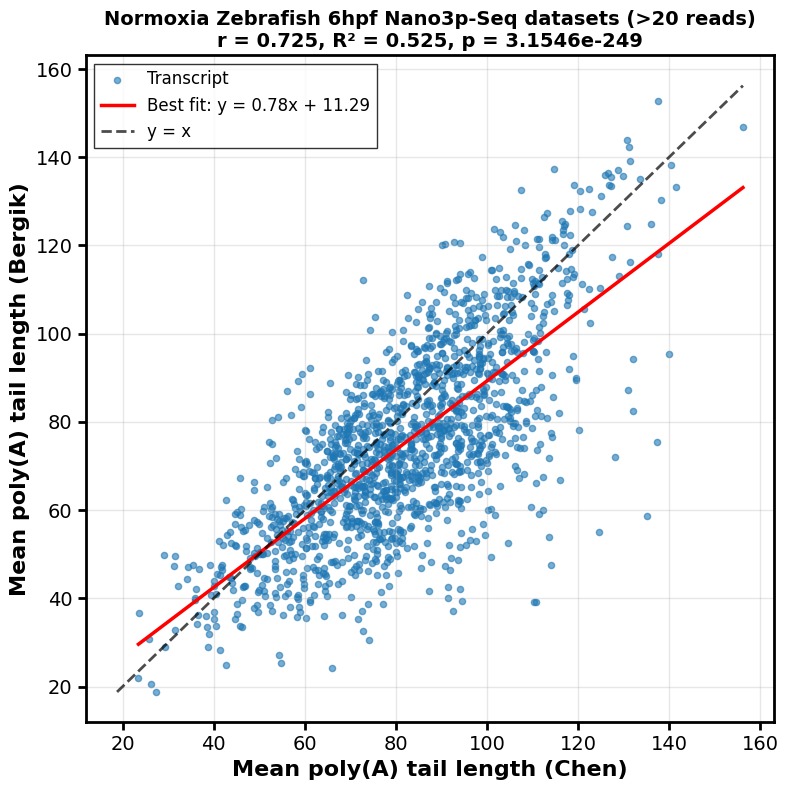

In [ ]:


# Filter bergik for 6hpf timepoint only
bergik_6hpf = bergik[bergik['Timepoint'] == '6hpf']

# Count reads per gene and filter for genes with >20 reads
bergik_counts = bergik_6hpf.groupby('Symbol').size()
bergik_genes_over_20 = bergik_counts[bergik_counts > 20].index

# Get mean tail_length for genes with >20 reads at 6hpf
tail_means = bergik_6hpf[bergik_6hpf['Symbol'].isin(bergik_genes_over_20)].groupby('Symbol')['tail_length'].mean().reset_index()
tail_means.columns = ['Symbol', 'mean_tail_length']

# Count reads per gene in df and filter for genes with >20 reads
df_counts = df.groupby('Gene').size()
df_genes_over_20 = df_counts[df_counts > 20].index

# Get mean adjusted_pt_length for genes with >20 reads
pt_means = df[df['Gene'].isin(df_genes_over_20)].groupby('Gene')['Adjusted_pt_length'].mean().reset_index()
pt_means.columns = ['Gene', 'mean_adjusted_pt']

# Merge the two dataframes on gene name
merged = tail_means.merge(pt_means, left_on='Symbol', right_on='Gene', how='inner')

print(f"Number of genes with >20 reads in both datasets: {len(merged)}")

# Calculate Pearson correlation and p-value
corr_coef, p_value = pearsonr(merged['mean_adjusted_pt'], merged['mean_tail_length'])
r_squared = corr_coef ** 2

# Print statistics
print(f"Pearson correlation coefficient: {corr_coef:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")

# Calculate line of best fit
x = merged['mean_adjusted_pt']
y = merged['mean_tail_length']
coefficients = np.polyfit(x, y, 1)
poly = np.poly1d(coefficients)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = poly(x_line)

# Create scatter plot with publication-ready styling
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot with smaller points
ax.scatter(merged['mean_adjusted_pt'], merged['mean_tail_length'],
           alpha=0.6, label='Transcript', s=20, color='#1f77b4')

# Add line of best fit
ax.plot(x_line, y_line, 'r-',
        label=f'Best fit: y = {coefficients[0]:.2f}x + {coefficients[1]:.2f}',
        linewidth=2.5)

# Add y=x line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--',
        label='y = x', linewidth=2, alpha=0.7)

# Formatting
ax.set_xlabel('Mean poly(A) tail length (Chen)', fontsize=16, fontweight='bold')
ax.set_ylabel('Mean poly(A) tail length (Bergik)', fontsize=16, fontweight='bold')
ax.set_title(f'Normoxia Zebrafish 6hpf Nano3p-Seq datasets (>20 reads)\nr = {corr_coef:.3f}, R² = {r_squared:.3f}, p = {p_value:.4e}',
             fontsize=14, fontweight='bold')

# Thicker axes and ticks
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(width=2, length=6, labelsize=14)

# Legend
ax.legend(fontsize=12, frameon=True, edgecolor='black', fancybox=False)

# Grid
ax.grid(True, alpha=0.3, linewidth=1)

plt.savefig('/your/path/BergikVsChen_normoxia6hpf_mean.png', dpi=600, bbox_inches='tight')


plt.tight_layout()
plt.show()